In [194]:
import pandas as pd

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [195]:
df = pd.read_csv('./dataset/cleaned_dataset.csv')

X = df.drop(columns=['Depression']).values
y = df['Depression'].values

In [196]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [197]:
model = Sequential([
    Input(shape=(X.shape[1],)),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

In [198]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [199]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 256)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,529 (213.00 KB)

 Trainable params: 54,529 (213.00 KB)

 Non-trainable params: 0 (0.00 B)

In [200]:
early_stopping = EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    mode='max',
    verbose=1
)

In [201]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    class_weight={
        0: 1,
        1: 1.3
    },
    verbose=1
)

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7721 - loss: 0.5122 - precision: 0.7506 - recall: 0.9109 - val_accuracy: 0.8563 - val_loss: 0.3334 - val_precision: 0.8657 - val_recall: 0.9007 - learning_rate: 5.0000e-04
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - accuracy: 0.8359 - loss: 0.4232 - precision: 0.8251 - recall: 0.9109 - val_accuracy: 0.8603 - val_loss: 0.3302 - val_precision: 0.8668 - val_recall: 0.9068 - learning_rate: 5.0000e-04
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.8423 - loss: 0.4133 - precision: 0.8313 - recall: 0.9145 - val_accuracy: 0.8575 - val_loss: 0.3284 - val_precision: 0.8598 - val_recall: 0.9115 - learning_rate: 5.0000e-04
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.8418 - loss: 0.4067 - precision: 0.8304 - recall: 0.9149 - val_accuracy: 0.8575 - val_loss: 0.3294 - val_precision: 0.8652 - val_recall: 0.9035 - learning_rate: 5.0000e-04
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s

In [202]:
import matplotlib.pyplot as plt

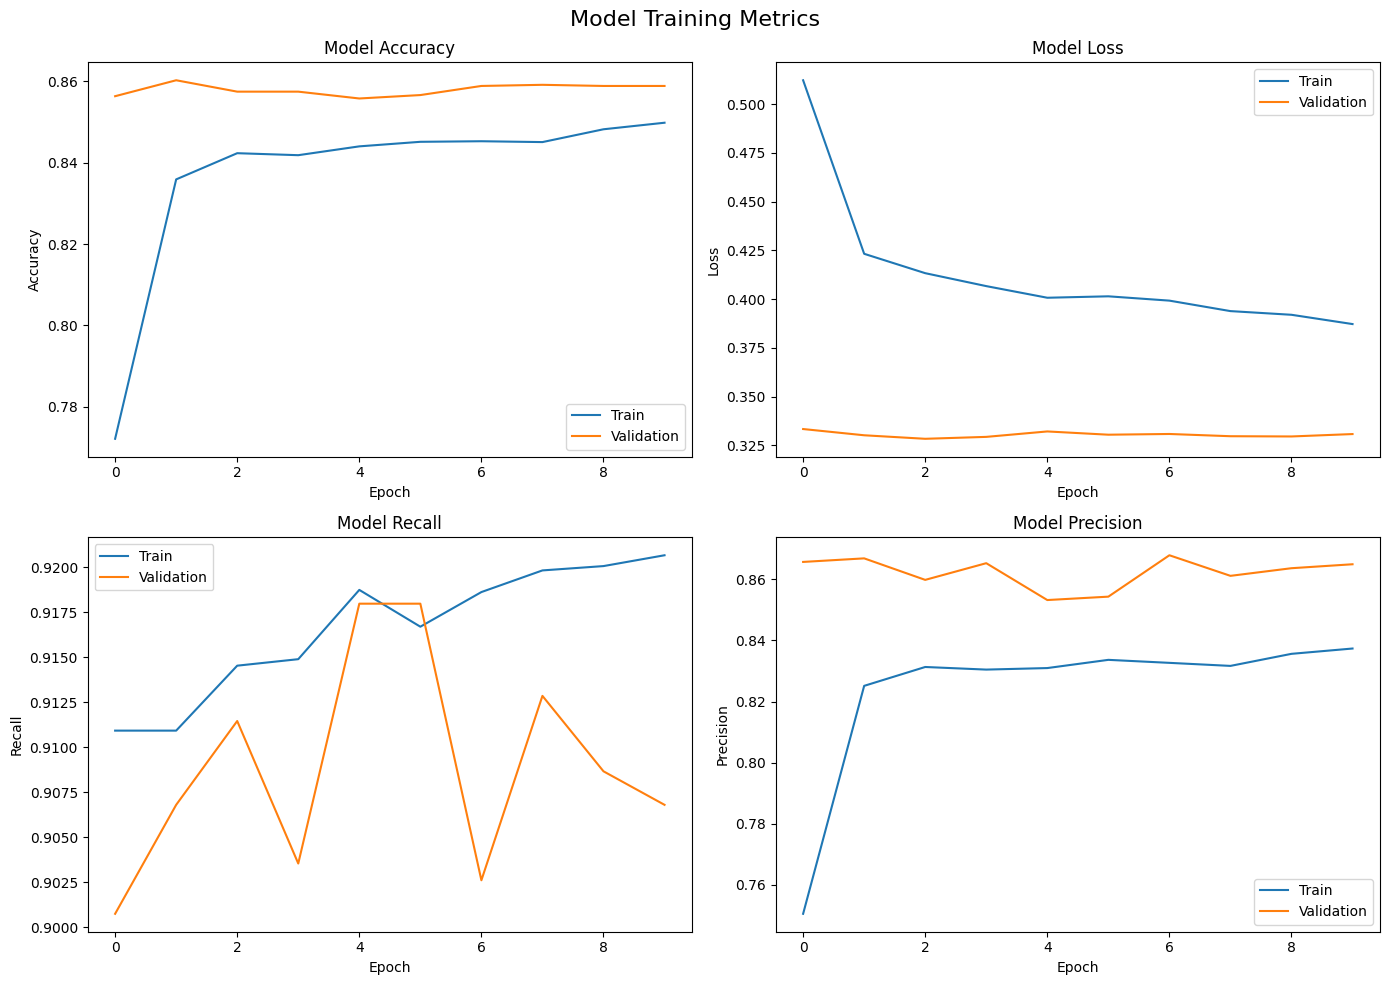

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'],     label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Loss
axes[0, 1].plot(history.history['loss'],     label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# Recall
axes[1, 0].plot(history.history['recall'],     label='Train')
axes[1, 0].plot(history.history['val_recall'], label='Validation')
axes[1, 0].set_title('Model Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()

# Precision
axes[1, 1].plot(history.history['precision'],     label='Train')
axes[1, 1].plot(history.history['val_precision'], label='Validation')
axes[1, 1].set_title('Model Precision')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

plt.suptitle('Model Training Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('./assets/real_training_metrics.png')
plt.show()

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step


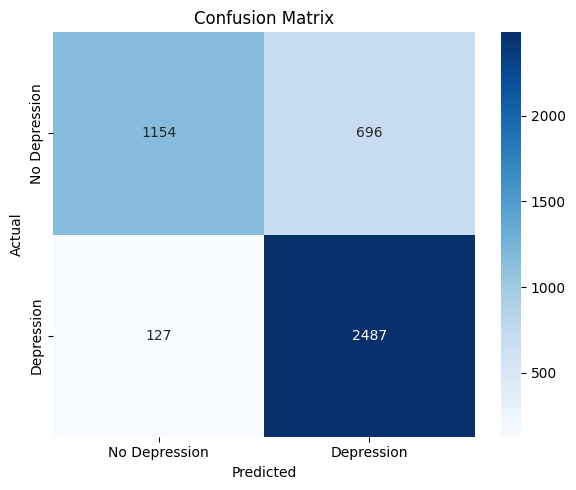

In [204]:
import seaborn as sns

y_pred = (model.predict(X_test) > 0.35).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('./assets/real_confusion_matrix.png')
plt.show()

In [205]:
report = classification_report(
    y_test,
    y_pred,
    target_names=['No Depression', 'Depression'],
    output_dict=True
)

# Convert to DataFrame
metrics_df = pd.DataFrame(report).transpose()

# Rename columns for clarity
metrics_df = metrics_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1-Score',
})

print(metrics_df[['Precision', 'Recall', 'F1-Score']].round(3))

               Precision  Recall  F1-Score
No Depression      0.901   0.624     0.737
Depression         0.781   0.951     0.858
accuracy           0.816   0.816     0.816
macro avg          0.841   0.788     0.798
weighted avg       0.831   0.816     0.808


In [206]:
model.save('./model/depression_model.h5')